# African Crises Dataset: EDA & Data Cleaning

**Objective:** Load the raw dataset, understand its structure, detect and handle missing values and outliers, and produce a clean dataset (`cleaned_crisis.csv`) for the feature engineering stage.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
%matplotlib inline
sns.set_style('whitegrid')

In [16]:
df = pd.read_csv('../data/african_crises.csv')

## 1. Initial Data Inspection

In [25]:
# Shape
print('Shape:', df.shape)

# Column dtypes
df.dtypes

Shape: (1059, 14)


case                                 int64
cc3                                    str
country                                str
year                                 int64
systemic_crisis                      int64
exch_usd                           float64
domestic_debt_in_default             int64
sovereign_external_debt_default      int64
gdp_weighted_default               float64
inflation_annual_cpi               float64
independence                         int64
currency_crises                      int64
inflation_crises                     int64
banking_crisis                         str
dtype: object

In [13]:
# Missing values per column (percentage)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({'Missing': missing, '%': missing_pct}).sort_values(by='%', ascending=False)

,Missing,%
case,0,0.0
cc3,0,0.0
country,0,0.0
year,0,0.0
systemic_crisis,0,0.0
exch_usd,0,0.0
domestic_debt_in_default,0,0.0
sovereign_external_debt_default,0,0.0
gdp_weighted_default,0,0.0
inflation_annual_cpi,0,0.0


In [10]:
df.describe(include='all')

,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
count,1059.000000,1059,1059,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1.059000e+03,1059.000000,1059.000000,1059.000000,1059
unique,NaN,13,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,EGY,Egypt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_crisis
freq,NaN,155,155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,965
mean,35.613787,NaN,NaN,1967.767705,0.077432,43.140831,0.039660,0.152975,0.006402,2.084889e+04,0.776204,0.132200,0.129367,NaN
std,23.692402,NaN,NaN,33.530632,0.267401,111.475380,0.195251,0.360133,0.043572,6.757274e+05,0.416984,0.349847,0.335765,NaN
min,1.000000,NaN,NaN,1860.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.850214e+01,0.000000,0.000000,0.000000,NaN
25%,15.000000,NaN,NaN,1951.000000,0.000000,0.195350,0.000000,0.000000,0.000000,2.086162e+00,1.000000,0.000000,0.000000,NaN
50%,38.000000,NaN,NaN,1973.000000,0.000000,0.868400,0.000000,0.000000,0.000000,5.762330e+00,1.000000,0.000000,0.000000,NaN
75%,56.000000,NaN,NaN,1994.000000,0.000000,8.462750,0.000000,0.000000,0.000000,1.164405e+01,1.000000,0.000000,0.000000,NaN


In [26]:
# Find the row with the maximum inflation
max_inflation_idx = df['inflation_annual_cpi'].idxmax()
df.iloc[max_inflation_idx][['country', 'year', 'inflation_annual_cpi']]

country                    Zimbabwe
year                           2008
inflation_annual_cpi    21989695.22
Name: 1053, dtype: object

In [27]:
df['systemic_crisis'].value_counts()


systemic_crisis
0    977
1     82
Name: count, dtype: int64

### Key observations from initial inspection (corrected)
- **No missing values** - all 1059 rows are complete.
- `banking_crisis` is a string column -> must be encoded to 0/1.
- `inflation_annual_cpi` max = 21.9 million (Zimbabwe hyperinflation)
- `exch_usd` has some zero values (likely errors) -> will be replaced by forward‑fill within each country.
- Target `systemic_crisis` mean = 7.7% -> strong class imbalance (only 82 positive cases).

## 2. Exploratory Visualisation

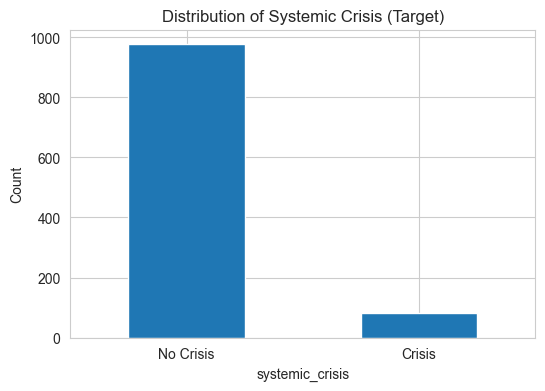

Crisis proportion: 0.077


In [28]:
plt.figure(figsize=(6,4))
df['systemic_crisis'].value_counts().plot(kind='bar')
plt.title('Distribution of Systemic Crisis (Target)')
plt.xticks([0,1], ['No Crisis', 'Crisis'], rotation=0)
plt.ylabel('Count')
plt.show()

print('Crisis proportion:', round(df['systemic_crisis'].mean(), 3))

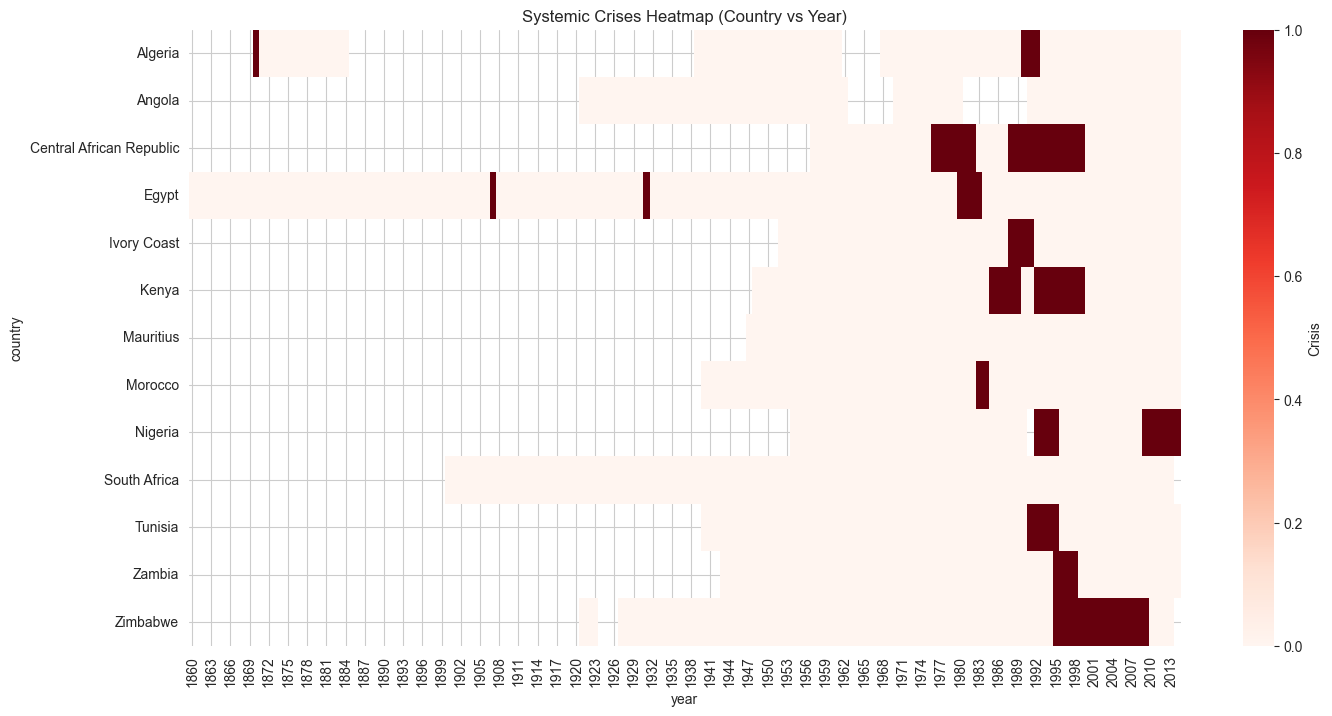

In [29]:
# countries as rows, years as columns, crisis as value
crisis_pivot = df.pivot_table(index='country', columns='year', values='systemic_crisis', aggfunc='max')

plt.figure(figsize=(16,8))
sns.heatmap(crisis_pivot, cmap='Reds', cbar_kws={'label': 'Crisis'}, linewidths=0)
plt.title('Systemic Crises Heatmap (Country vs Year)')
plt.show()

### Why these four countries?

| Country | Reason for selection |
|---------|----------------------|
| **Egypt** | One of the longest time series (from 1860), many early crisis episodes, relatively moderate exchange rate movements. |
| **South Africa** | A major African economy with a mix of crises and calm periods; exchange rate changes after the 1970s are modest but volatile. |
| **Algeria** | Clear late‑20th‑century crisis cluster (banking crises) with high inflation and exchange rate spikes – useful to see the relationship between inflation and crisis. |
| **Zimbabwe** | The extreme case: hyperinflation and a currency that collapsed. Shows why capping is necessary and what a severe crisis looks like in the raw data. |

Together they cover **North, Southern, and East‑West Africa**, a very long history (Egypt), hyperinflation (Zimbabwe), and typical crisis patterns (Algeria, South Africa).
This selection illustrates three key patterns in the data:
- **Long stable periods with occasional shocks** (Egypt, South Africa)
- **Frequent, clustered crises** (Algeria)
- **Extreme outliers that must be handled** (Zimbabwe)

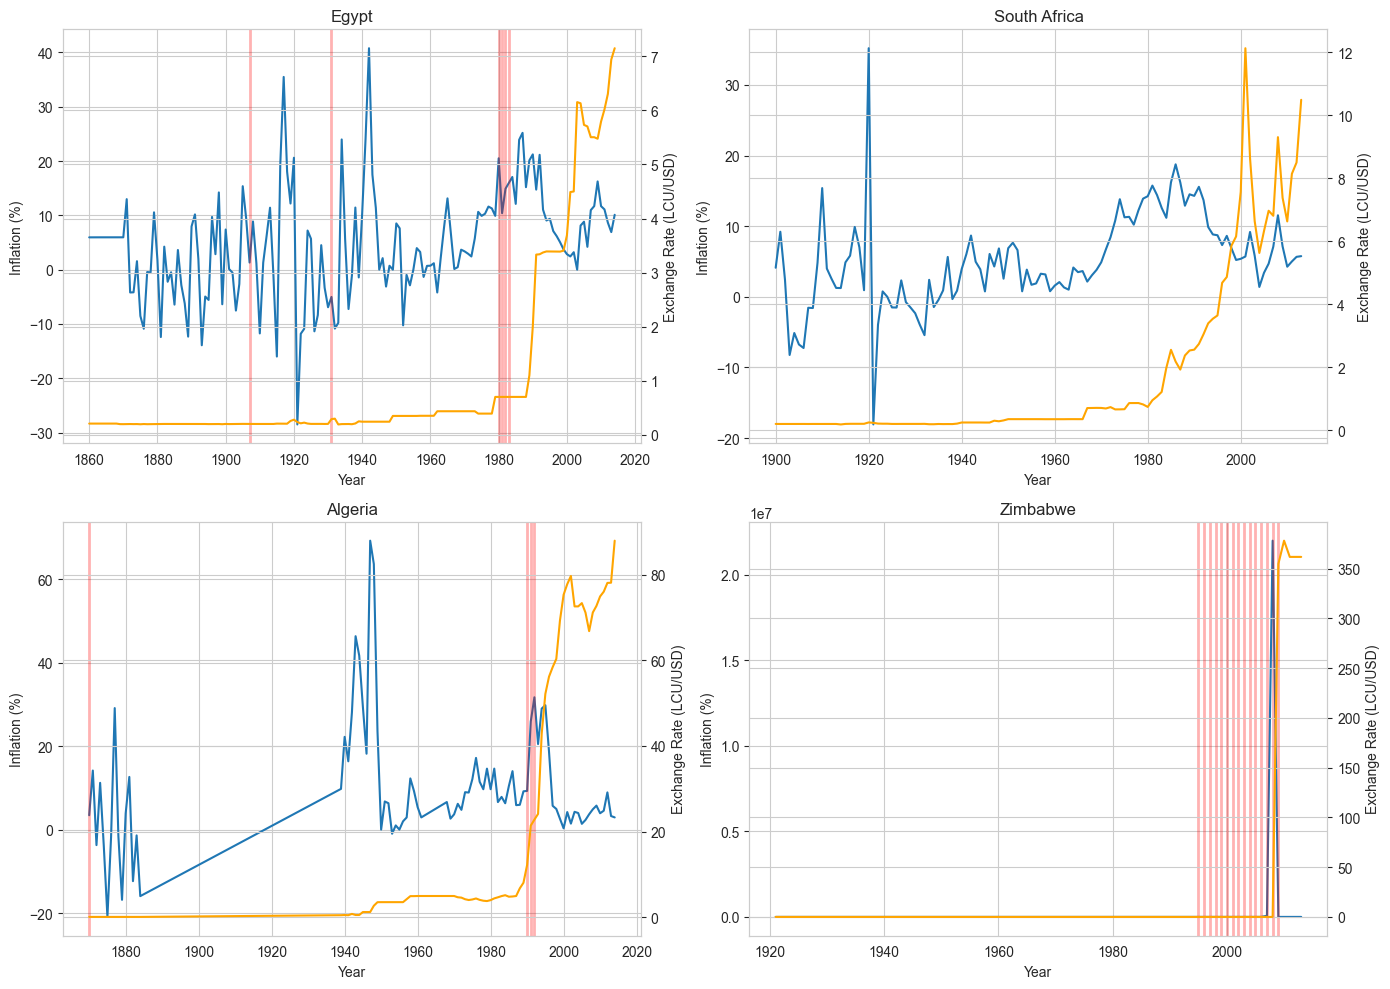

In [33]:
sample_countries = ['Egypt', 'South Africa', 'Algeria', 'Zimbabwe']
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.ravel()

for i, country in enumerate(sample_countries):
    country_df = df[df['country'] == country]
    ax = axes[i]
    ax.plot(country_df['year'], country_df['inflation_annual_cpi'], label='Inflation')
    ax2 = ax.twinx()
    ax2.plot(country_df['year'], country_df['exch_usd'], color='orange', label='Exchange Rate')
    # Highlight crisis years
    crisis_years = country_df[country_df['systemic_crisis']==1]['year']
    for y in crisis_years:
        ax.axvline(x=y, color='red', alpha=0.3, linewidth=2)
    ax.set_title(country)
    ax.set_xlabel('Year')
    ax.set_ylabel('Inflation (%)')
    ax2.set_ylabel('Exchange Rate (LCU/USD)')
plt.tight_layout()
plt.show()

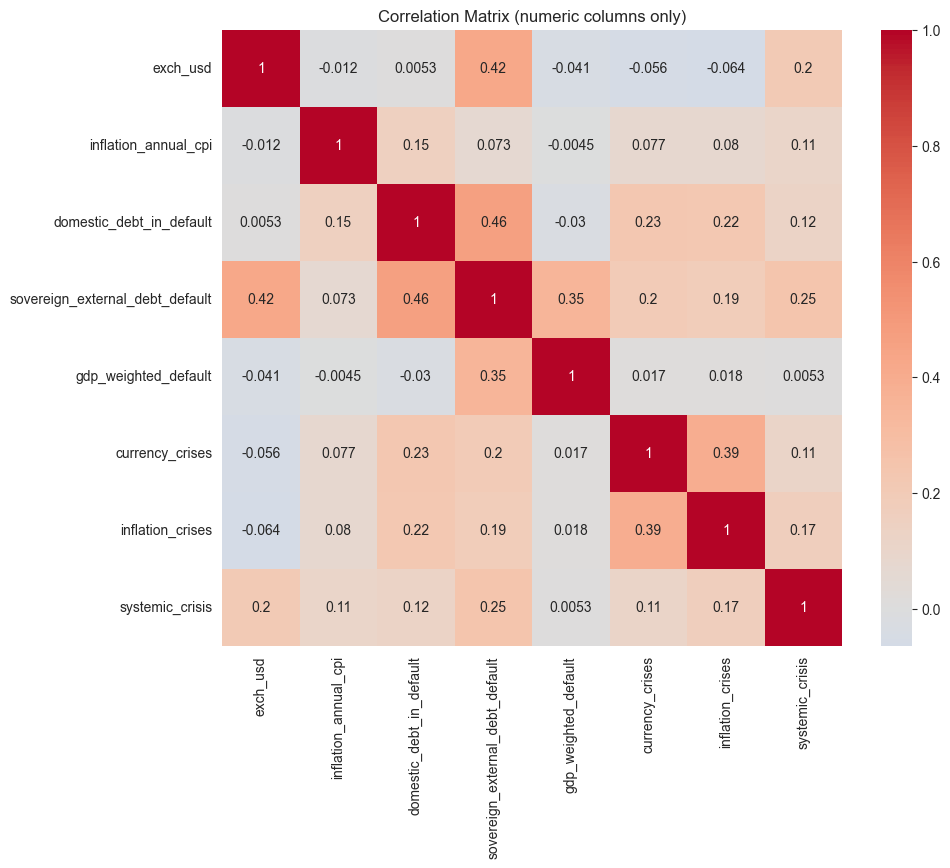

In [35]:
numeric_cols = ['exch_usd', 'inflation_annual_cpi', 'domestic_debt_in_default',
                'sovereign_external_debt_default', 'gdp_weighted_default',
                'currency_crises', 'inflation_crises', 'systemic_crisis']

corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (numeric columns only)')
plt.show()

## 3. Data Cleaning

In [36]:
df_clean = df.copy()

# Encode banking_crisis from string to numeric (1 = crisis, 0 = no_crisis)
df_clean['banking_crisis'] = df_clean['banking_crisis'].map({'crisis': 1, 'no_crisis': 0})

print(df_clean['banking_crisis'].value_counts())

banking_crisis
0    965
1     94
Name: count, dtype: int64


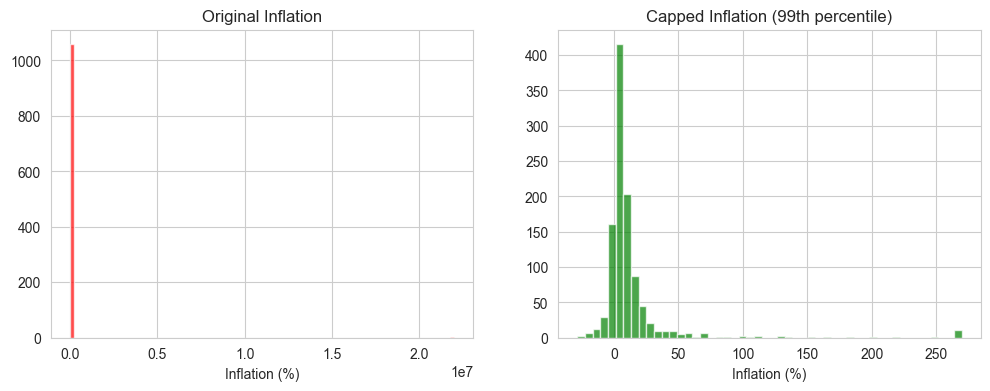

In [37]:
#outlier capping
# Cap inflation at 99th percentile
infl_cap = df_clean['inflation_annual_cpi'].quantile(0.99)
df_clean['inflation_capped'] = df_clean['inflation_annual_cpi'].clip(upper=infl_cap)

# Cap exchange rate at 99th percentile
exch_cap = df_clean['exch_usd'].quantile(0.99)
df_clean['exch_usd_capped'] = df_clean['exch_usd'].clip(upper=exch_cap)

# Visualise before/after for inflation
fig, axs = plt.subplots(1, 2, figsize=(12,4))
axs[0].hist(df_clean['inflation_annual_cpi'], bins=100, color='red', alpha=0.7)
axs[0].set_title('Original Inflation')
axs[0].set_xlabel('Inflation (%)')
axs[1].hist(df_clean['inflation_capped'], bins=50, color='green', alpha=0.7)
axs[1].set_title('Capped Inflation (99th percentile)')
axs[1].set_xlabel('Inflation (%)')
plt.show()

In [39]:
# Replace zero exchange rates with NaN, then forward‑fill within each country
df_clean['exch_usd_capped'] = df_clean['exch_usd_capped'].replace(0, np.nan)
df_clean['exch_usd_capped'] = df_clean.groupby('country')['exch_usd_capped'].ffill()


print('Zeros remaining:', (df_clean['exch_usd_capped'] == 0).sum())

Zeros remaining: 0


In [42]:
# Ensure no missing values in key columns
print(df_clean[['inflation_capped', 'exch_usd_capped', 'banking_crisis']].isnull().sum())
print('Final shape:', df_clean.shape)

inflation_capped    0
exch_usd_capped     0
banking_crisis      0
dtype: int64
Final shape: (1059, 16)


### Summary of Cleaning Decisions
- **Encoding:** `banking_crisis` converted from string (`crisis`/`no_crisis`) to binary (1/0).
- **Outliers:** Inflation and exchange rate capped at their 99th percentile to prevent extreme hyperinflation (Zimbabwe 2008) from distorting the models.
- **Zero exchange rates:** Replaced by forward‑fill (and back‑fill for initial rows) within each country.
- **Final check:** All key columns have **zero missing values**; the dataset retains all 1059 rows.


## 4. Export Cleaned Dataset

In [43]:
df_clean.to_csv('../data/cleaned_crisis.csv', index=False)
print('Cleaned data saved to ../data/cleaned_crisis.csv')

Cleaned data saved to ../data/cleaned_crisis.csv


### Additional data quality checks

In [47]:
# Unique countries and their data range
countries = df.groupby('country')['year'].agg(['min', 'max', 'count'])
countries.columns = ['start_year', 'end_year', 'n_years']
print(countries.sort_values('start_year'))

                          start_year  end_year  n_years
country                                                
Egypt                           1860      2014      155
Algeria                         1870      2014       85
South Africa                    1900      2013      114
Angola                          1921      2014       77
Zimbabwe                        1921      2013       90
Tunisia                         1940      2014       75
Morocco                         1940      2014       75
Zambia                          1943      2014       72
Mauritius                       1947      2014       68
Kenya                           1948      2014       67
Ivory Coast                     1952      2014       63
Nigeria                         1954      2014       60
Central African Republic        1957      2014       58
